In [1]:
# test with supervised optimal transport loss
# comparison with unsupervised

import random
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import GradScaler
from torch.utils.data import DataLoader
import deeplake
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.decomposition import PCA
from geomloss import SamplesLoss
import time
import pandas as pd
from torch.utils.data import ConcatDataset, RandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
import pickle
import seaborn as sns
import itertools
from dataset_OT import make_multi_WSI_dataset

seed = 42
torch.manual_seed(seed)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False 


batch_size = 512 

print('Loading starting...')
idx_range_subset1 = [i for i in range(1,52+1)]
random.shuffle(idx_range_subset1)
num_train = int(np.ceil(0.7 * len(idx_range_subset1))) 
train_range1, val_range1 = idx_range_subset1[:num_train], idx_range_subset1[num_train:]

idx_range_subset3 = [i for i in range(1,26+1)] 
random.shuffle(idx_range_subset3)
num_train = int(np.ceil(0.7 * len(idx_range_subset3))) 
train_range3, val_range3 = idx_range_subset3[:num_train], idx_range_subset3[num_train:]

akoya_loader_train_subset1 = make_multi_WSI_dataset('Subset1', train_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
akoya_loader_val_subset1 = make_multi_WSI_dataset('Subset1', val_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
akoya_loader_train_subset3 = make_multi_WSI_dataset('Subset3', train_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
akoya_loader_val_subset3 = make_multi_WSI_dataset('Subset3', val_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
leica_loader_train = make_multi_WSI_dataset('Subset3', train_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)
leica_loader_val = make_multi_WSI_dataset('Subset3', val_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)

akoya_loader_train = ConcatDataset([akoya_loader_train_subset1, akoya_loader_train_subset3])
akoya_loader_val = ConcatDataset([akoya_loader_val_subset1, akoya_loader_val_subset3])

len_akoya_train = len(akoya_loader_train)
len_akoya_val = len(akoya_loader_val)

len_leica_train = len(leica_loader_train)
len_leica_val = len(leica_loader_val)

len_train = len_akoya_train + len_leica_train
len_val = len_akoya_val + len_leica_val

B_A_train = round(batch_size * len_akoya_train / (len_akoya_train + len_leica_train))
B_L_train = batch_size - B_A_train 
B_A_val = round(batch_size * len_akoya_val / (len_akoya_val + len_leica_val))
B_L_val = batch_size - B_A_val

akoya_loader_train = DataLoader(akoya_loader_train, batch_size=B_A_train, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
akoya_loader_val = DataLoader(akoya_loader_val, batch_size=B_A_val, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
leica_loader_train = DataLoader(leica_loader_train, batch_size=B_L_train, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
leica_loader_val = DataLoader(leica_loader_val, batch_size=B_L_val, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)

#leica_train_iter = itertools.cycle(iter(leica_loader_train))
#leica_val_iter = itertools.cycle(iter(leica_loader_val)) #????

print("Train batches Akoya:", len(akoya_loader_train), 'batch size:', B_A_train)
print("Train batches Leica:", len(leica_loader_train), 'batch size:', B_L_train)
print("Validation batches Akoya:", len(akoya_loader_val), 'batch size:', B_A_val)
print("Validation batches Leica:", len(leica_loader_val), 'batch size:', B_L_val)

#in samples
print('len train:', len_train)


loss_geom = SamplesLoss('sinkhorn', p=2, blur=0.1, scaling=0.95, verbose=False)


Loading starting...
Train batches Akoya: 4973 batch size: 399
Train batches Leica: 4978 batch size: 113
Validation batches Akoya: 1272 batch size: 388
Validation batches Leica: 1267 batch size: 124
len train: 2546444


In [2]:
# unsupervised
loss_geom = SamplesLoss('sinkhorn', p=2, blur=0.1, scaling=0.95, verbose=False)



In [3]:


dic={0:[], 1:[],2:[],3:[],4:[]}
def supervised_OT_loss(embedding_akoya, embedding_leica, labels_akoya, labels_leica):
    OT_loss = embedding_akoya.new_zeros(()) #creates a new tensor with the same dtype and device, with () --> scalar shape
    device = embedding_akoya.device
    
    uniq_akoya = torch.unique(labels_akoya)
    uniq_leica = torch.unique(labels_leica)
    common_labels = uniq_akoya[torch.isin(uniq_akoya, uniq_leica)]

    
    for label in common_labels:
        akoya_idx = labels_akoya == label
        leica_idx = labels_leica == label
        akoya_emb = embedding_akoya[akoya_idx]
        leica_emb = embedding_leica[leica_idx]
        
        label_OT = loss_geom(akoya_emb, leica_emb)
        OT_loss.add_(label_OT) #in place operation
        
        return OT_loss
#try the version with the modified cost matrix







In [4]:
go = True
lu_OT = []
ls_OT = []
sup_times, unsup_times = [], []
avg_sup = 0
avg_unsup = 0
device = torch.device('cuda')

tq = tqdm(zip(akoya_loader_train, leica_loader_train),
                                                    desc=f"Timing OT losses",
                                                    total=min(len(akoya_loader_train), len(leica_loader_train)))

if go:
    total_time = 0
    for batch_akoya, batch_leica in tq:
                
        
        embedding_akoya = batch_akoya['embedding'].to(device, non_blocking=True)
        embedding_leica = batch_leica['embedding'].to(device, non_blocking=True)
        labels_akoya = batch_akoya['label'].to(device, non_blocking=True)
        labels_leica = batch_leica['label'].to(device, non_blocking=True)
        
        # supervised OT
        t0 = time.time()
        s_OT = supervised_OT_loss(embedding_akoya, embedding_leica, labels_akoya, labels_leica).cpu().detach().item()
        ls_OT.append(s_OT)
        t1 = time.time()
        sup_times.append(t1 - t0)
        
        # unsupervised OT
        t2 = time.time()
        u_OT = loss_geom(embedding_akoya, embedding_leica).cpu().detach().item()
        lu_OT.append(u_OT)
        t3 = time.time()
        unsup_times.append(t3 - t2)
        
        # update tqdm description with average times so far
        avg_sup = sum(sup_times) / len(sup_times)
        avg_unsup = sum(unsup_times) / len(unsup_times)
        tq.set_description(f"Timing OT losses | Avg sup: {avg_sup:.3f}s | Avg unsup: {avg_unsup:.3f}s")
    
    

Timing OT losses | Avg sup: 0.066s | Avg unsup: 0.059s: 100%|█████████████████████████████████████| 4973/4973 [10:30<00:00,  7.89it/s]


/tmp/ipykernel_2047960/2810853781.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  axes[1,0].plot(np.array(torch.tensor(dic[0])), label='s_OT Normal') #std 16, median 509
/tmp/ipykernel_2047960/2810853781.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  axes[1,1].plot(np.array(torch.tensor(dic[1])), label='s_OT Stroma') #std 30 median 440
/tmp/ipykernel_2047960/2810853781.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing c

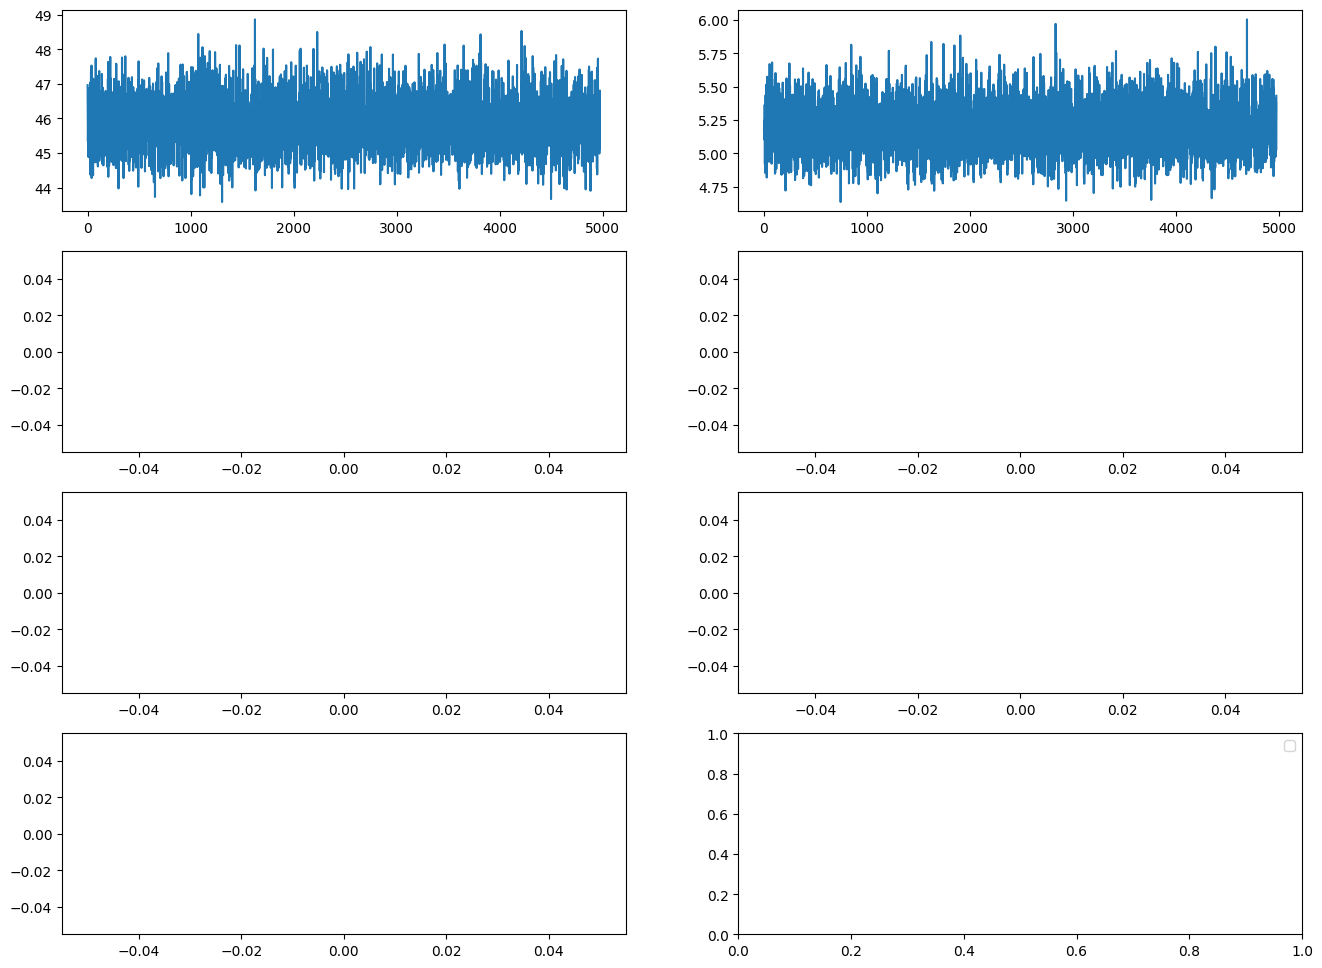

Basic Statistics for lu_OT:
Mean: 5.194770260443995
Median: 5.188341064453125
Standard Deviation: 0.17866977382979887
Variance: 0.03192288808039148
Minimum: 4.63587158203125
Maximum: 6.0021923828125


In [6]:
import matplotlib.pyplot as plt
lu_OT_array = np.array(lu_OT) *0.1
ls_OT_array = np.array(ls_OT) * 0.01

 
fig, axes = plt.subplots(4,2, figsize=(16, 12))

#no weigthing scheme
axes[0,0].plot(lu_OT_array, label='lu') #7, median 458
axes[0,1].plot(ls_OT_array, label='ls') #std 302, median 2300
axes[1,0].plot(np.array(torch.tensor(dic[0])), label='s_OT Normal') #std 16, median 509
axes[1,1].plot(np.array(torch.tensor(dic[1])), label='s_OT Stroma') #std 30 median 440
axes[2,0].plot(np.array(torch.tensor(dic[2])), label='s_OT G3') #std 12, median 420
axes[2,1].plot(np.array(torch.tensor(dic[3])), label='s_OT G4') #std 10, median 433
axes[3,0].plot(np.array(torch.tensor(dic[4])), label='s_OT G5') #std 70, median 590
plt.legend()
#its as if the OT based loss was already performing the weighting scheme for  G5
 #7, median 440 (but only on 9% of data)



#plt.title('Plot of u_OT and s_OT')
#plt.legend()
plt.savefig('label-OT.pdf')
# Show the plot
plt.show()



hello = ls_OT_array
# Basic statistics
print("Basic Statistics for lu_OT:")
print(f"Mean: {np.mean(hello)}")
print(f"Median: {np.median(hello)}")
print(f"Standard Deviation: {np.std(hello)}")
print(f"Variance: {np.var(hello)}")
print(f"Minimum: {np.min(hello)}")
print(f"Maximum: {np.max(hello)}")



#with the scaling factor 0.1, the std is below one for unsupervised learning, 
#even with the scaling factor, the std of my supervised technique is high (=22)
#lets understand why: too much weight given to G5
#analyse the distribution of label OT losses to understand how we can weigth the sum

In [1]:
import torch
import gc

def cleanup_gpu():
    """
    Libère la mémoire GPU et CPU (objets Python + cache CUDA).
    À appeler après un entraînement ou quand tu veux forcer un reset mémoire.
    """
    gc.collect()                                # garbage collector Python
    torch.cuda.empty_cache()                    # vide le cache mémoire CUDA
    torch.cuda.ipc_collect()                    # récupère la mémoire inter-processus
    torch.cuda.synchronize()                    # s'assure que tout est bien fini
    print(f"[GPU cleanup] Memory cleared on {torch.cuda.current_device()}")
cleanup_gpu()

[GPU cleanup] Memory cleared on 0


Bad pipe message: %s [b'\n\xf0\xa8ro\xfd\x0e\xd7l\xfb\x10\x0c\xad \xc6\xc7\xd1O\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x8a\x00\x8b\x00\x8c\x00\x8d\x00\x8e\x00\x8f\x00\x90\x00\x91\x00\x92\x00\x93\x00\x94\x00\x95\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6']
Bad pipe message: %s [b'X\x8c\x1e\x9axdd\xb3b\x92_v\x18:\xc3H\xd9}\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\